# Dynamic Routing

Dynamic routing means **deciding the next node at runtime** based on the current state or result.

```python
return Command(goto="doctor")
```

Instead of defining a fixed outgoing edge, the node itself decides where to go.

**Use when:** the destination depends on information discovered during execution.

---

# Dynamic State Update

Dynamic state update means **updating state with values determined at runtime**.

```python
return Command(
    update={"appointment_type": appointment_type}
)
```

The value being stored is calculated/read during execution.

---

### Together

`Command` can perform both:

```python
return Command(
    update={"selected_type": appointment_type},
    goto=f"{appointment_type}_appointment"
)
```

**In short:**

* `goto` → **Where should the workflow go?**
* `update` → **What state should be changed?**
* `Command` → **Do both from the current node.**

---

# Problem: Appointment Booking

Create a LangGraph workflow for booking appointments.

**Input:**

* `name`
* `appointment_type` (`doctor`, `dentist`, `eye`)

**Workflow:**

```text
START → Router → [Doctor | Dentist | Eye] → END
```

**Requirements:**

* Create a router node.
* Dynamically route using `Command(goto=...)`.
* Update `selected_type` using `Command(update=...)`.
* Do **not** use conditional edges.

**Goal:** Practice dynamic routing with `Command`.

---


In [35]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langgraph.types import Command
from typing import TypedDict, Literal, Annotated
from pydantic import BaseModel, Field
from operator import add



In [36]:
llm = ChatGoogleGenerativeAI(
    model = "gemini-3.1-flash-lite",
    temperature=0.6
)


In [37]:
# define schemas

class StateSchema(TypedDict):
    message: str
    name: str
    meeting_with: Literal["doctor", "dentist", "eye"]
    appointments: Annotated[list[str], add]

class LLMOutput(BaseModel):
    name: str = Field(description="name of the user")
    meeting_with: Literal["doctor", "dentist", "eye"] = Field(description="user want's to book appointment with the person", default="doctor")



In [38]:
def llm_node(state: StateSchema):
    message = state["message"]
    appointments = state["appointments"]

    prompt = PromptTemplate(
        template="""
you are an appointment booking manager.
indetify the information mentioned in the given message.

Note:
user can book appointment with one person at a time. 
if user want's to book multiple appointments,
then check which appointment has already booked and then move forward with next appointment

message: {message}
Here are the list for which appointments are already booked: {appointments}""",
        input_variables=["message", "appointments"]
    )

    structured_llm = llm.with_structured_output(schema=LLMOutput)

    chain = prompt | structured_llm

    resp = chain.invoke({"message": message, "appointments": appointments})

    return {
        "name": resp.name,
        "meeting_with": resp.meeting_with
    }


In [39]:
def router(state: StateSchema):
    return Command(goto=state["meeting_with"])

def doctor_node(state: StateSchema):
    msg = "Appointment Booked with Doctor"
    return {
        "appointments": [msg]
    }

def dentist_node(state: StateSchema):
    msg = "Appointment Booked with Dentist"
    return {
        "appointments": [msg]
    }

def eye_node(state: StateSchema):
    msg = "Appointment Booked for Eye Checkup"
    return {
        "appointments": [msg]
    }

In [45]:
builder = StateGraph(StateSchema)
builder.add_node("llm_node", llm_node)
builder.add_node("doctor", doctor_node)
builder.add_node("eye", eye_node)
builder.add_node("dentist", dentist_node)
builder.add_node("router", router)


builder.add_edge(START, "llm_node")
builder.add_edge("llm_node", "router")
builder.add_edge("llm_node", add)


# If router uses Command(goto=...) for dynamic routing, you should not add these three edges:
# builder.add_edge("router", "doctor")
# builder.add_edge("router", "eye")
# builder.add_edge("router", "dentist")

builder.add_edge("doctor", END)
builder.add_edge("eye", END)
builder.add_edge("dentist", END)

graph = builder.compile()
    

ValueError: Found edge ending at unknown node `<built-in function add>`

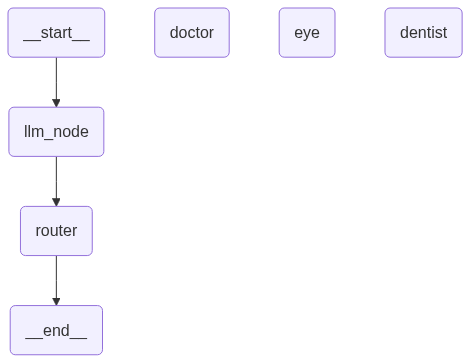

In [ ]:
graph

In [48]:
resp = graph.invoke({"message": "I am bhavin, book an appointment with eye doctor" })

In [49]:
resp

{'message': 'I am bhavin, book an appointment with eye doctor',
 'name': 'bhavin',
 'meeting_with': 'eye',
 'appointments': ['Appointment Booked for Eye Checkup']}